<div style="background:linear-gradient(135deg,#1e1b4b 0%,#4338ca 55%,#6366f1 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#c7d2fe;font-weight:700;text-transform:uppercase">Chapter 80 · Hypothesis Testing &amp; Inference</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Nonparametric Tests 🔢</div>
  <div style="font-size:15px;color:#eef2ff;max-width:740px;line-height:1.6">When data are skewed, outlier-ridden, or merely ordinal, mean-based tests get shaky. Rank-based nonparametric tests stay robust. We build Mann-Whitney U, Kruskal-Wallis, and Wilcoxon signed-rank, then apply them to heavily skewed support-ticket times.</div>
  <div style="margin-top:16px;font-size:13px;color:#c7d2fe">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
# statsmodels = the R/SAS-style stats library (pre-installed on Colab): it computes the
# standard errors, test statistics, intervals, and post-hoc comparisons, so we write less by hand.
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep, proportion_confint
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.weightstats import DescrStatsW, CompareMeans
from scipy.stats.contingency import association   # Cramer's V in one call
IND="#4f46e5"; DEEP="#4338ca"; LIGHT="#818cf8"; INK="#1a2138"; GRID="#e6e9f2"; GREEN="#059669"; RED="#ef4444"; AMBER="#d97706"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
rng = np.random.default_rng(80)

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#4338ca;letter-spacing:1px">DEMO 1 · WHEN THE t-TEST BREAKS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Skew, outliers, and ordinal data</div>
<div style="color:#4a5578;margin-top:6px">Parametric tests (z, t, ANOVA) assume roughly normal data and care about MEANS, which a single outlier can wreck. Nonparametric tests work on RANKS instead, so they shrug off skew and outliers and even handle ordinal (ordered-category) data.</div>
</div>

In [2]:
clean = rng.normal(50, 8, 40)
dirty = clean.copy(); dirty[0] = 400      # one fat-fingered outlier
print(f"clean mean={clean.mean():.1f}, with-outlier mean={dirty.mean():.1f}  <- mean is wrecked")
print(f"clean median={np.median(clean):.1f}, with-outlier median={np.median(dirty):.1f}  <- median barely moves")
print("Rank-based tests inherit the median\u2019s robustness: the outlier is merely the largest rank.")

clean mean=49.9, with-outlier mean=58.5  <- mean is wrecked
clean median=48.5, with-outlier median=48.5  <- median barely moves
Rank-based tests inherit the median’s robustness: the outlier is merely the largest rank.


The mean (and any test built on it) is dragged around by outliers and skew; the median and ranks are not. When the data are heavy-tailed, badly skewed, or merely ordinal (like 1-5 ratings), a rank-based test is the honest choice.

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#4338ca;letter-spacing:1px">DEMO 2 · MANN-WHITNEY U</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The rank-based answer to the two-sample t-test</div>
<div style="color:#4a5578;margin-top:6px">The Mann-Whitney U test (a.k.a. Wilcoxon rank-sum) compares two independent groups by pooling all values, ranking them, and asking whether one group's ranks tend to be higher. No normality assumption; it tests whether one distribution is shifted from the other.</div>
</div>

In [3]:
a = rng.lognormal(1.0, 0.6, 60)   # skewed group A
b = rng.lognormal(0.7, 0.6, 70)   # skewed group B (shifted lower)
u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
print(f"median A = {np.median(a):.2f}, median B = {np.median(b):.2f}")
print(f"Mann-Whitney U = {u:.1f}, p = {p:.4f}")
print(f"(a t-test on this skewed data would be less trustworthy: t-p = {stats.ttest_ind(a,b).pvalue:.4f})")

median A = 2.81, median B = 2.09
Mann-Whitney U = 2634.0, p = 0.0127
(a t-test on this skewed data would be less trustworthy: t-p = 0.0172)


Mann-Whitney compares the whole rank ordering, so it answers "does one group tend to be larger?" without trusting means or normality. It is the default two-group test whenever the data are skewed, heavy-tailed, or ordinal.

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#4338ca;letter-spacing:1px">DEMO 3 · KRUSKAL-WALLIS & WILCOXON</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Nonparametric ANOVA, and the paired version</div>
<div style="color:#4a5578;margin-top:6px">Kruskal-Wallis is the rank-based extension to 3+ groups (the nonparametric ANOVA). For PAIRED data, the Wilcoxon signed-rank test replaces the paired t-test, ranking the within-pair differences.</div>
</div>

In [4]:
g1=rng.lognormal(1.0,0.5,40); g2=rng.lognormal(1.2,0.5,40); g3=rng.lognormal(1.5,0.5,40)
H,p = stats.kruskal(g1,g2,g3)
print(f"Kruskal-Wallis across 3 groups: H={H:.2f}, p={p:.4f}")
before=rng.lognormal(1.2,0.4,30); after=before*rng.uniform(0.7,0.95,30)  # paired drop
w,pw = stats.wilcoxon(after, before)
print(f"Wilcoxon signed-rank (paired): W={w:.1f}, p={pw:.4f}")

Kruskal-Wallis across 3 groups: H=10.72, p=0.0047
Wilcoxon signed-rank (paired): W=0.0, p=0.0000


Kruskal-Wallis is to ANOVA what Mann-Whitney is to the t-test, a one-way comparison of 3+ groups on ranks. Wilcoxon signed-rank is the paired partner, the robust replacement for the paired t-test when differences are skewed. Each maps cleanly onto a parametric cousin.

<div style="background:#ecfdf5;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">REAL-WORLD EXAMPLE · TICKET RESOLUTION TIMES</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Skewed support data where ranks are the safe choice</div>
<div style="color:#4a5578;margin-top:6px"></div>
</div>

A support org logs ticket resolution times (`nonparametric-tests--ticket_times.xlsx`). Resolution time is heavily right-skewed (most tickets fast, a few very slow), so the mean is misleading and the t-test is shaky. We compare two teams (Mann-Whitney) and three priority levels (Kruskal-Wallis) on ranks.

In [5]:
try:    d = pd.read_excel("../../data/nonparametric-tests--ticket_times.xlsx", sheet_name="Tickets")
except FileNotFoundError: d = pd.read_excel(BASE+"nonparametric-tests--ticket_times.xlsx", sheet_name="Tickets")
# EXPLORE FIRST: size, missing, per-team summary, and the (telling) skewness
print("shape:", d.shape, "| missing:", d.isna().sum().sum())
print(d.groupby("team").resolution_hours.agg(["size","median","mean","max"]).round(2))
print(f"\nresolution_hours skewness = {stats.skew(d.resolution_hours):.2f} (strongly right-skewed -> ranks, not means)")
A=d[d.team=="Alpha"].resolution_hours; B=d[d.team=="Bravo"].resolution_hours
u,p = stats.mannwhitneyu(A,B,alternative="two-sided")
print(f"Alpha median={A.median():.2f} h, Bravo median={B.median():.2f} h")
print(f"[MANN-WHITNEY] U={u:.1f}, p={p:.4f} -> {'teams differ' if p<0.05 else 'no clear difference'}")
print(f"[EFFECT SIZE]  rank-biserial r = {1 - 2*u/(len(A)*len(B)):+.2f}  (|0.1| small, |0.3| medium, |0.5| large)")

shape: (240, 5) | missing: 0
       size  median   mean    max
team                             
Alpha   119    9.63  12.78  75.01
Bravo   121    7.77   9.84  40.11

resolution_hours skewness = 2.49 (strongly right-skewed -> ranks, not means)
Alpha median=9.63 h, Bravo median=7.77 h
[MANN-WHITNEY] U=8268.5, p=0.0469 -> teams differ
[EFFECT SIZE]  rank-biserial r = -0.15  (|0.1| small, |0.3| medium, |0.5| large)


medians by priority: {'High': np.float64(5.02), 'Low': np.float64(11.16), 'Medium': np.float64(6.92)}
[KRUSKAL-WALLIS] H=29.59, p=3.76e-07 -> priorities differ


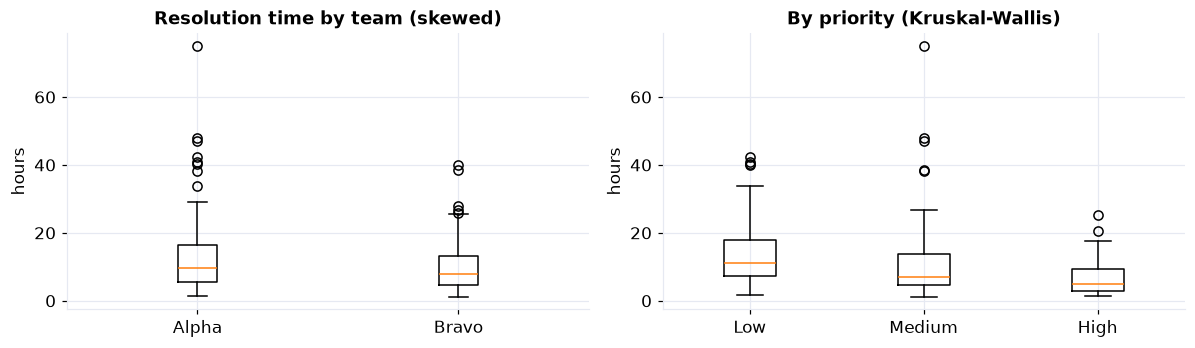

In [6]:
groups=[g.resolution_hours.values for _,g in d.groupby("priority")]
names=list(d.groupby("priority").groups.keys())
H,p = stats.kruskal(*groups)
meds={k:round(d[d.priority==k].resolution_hours.median(),2) for k in names}
print(f"medians by priority: {meds}")
print(f"[KRUSKAL-WALLIS] H={H:.2f}, p={p:.2e} -> {'priorities differ' if p<0.05 else 'no difference'}")
fig,ax=plt.subplots(1,2,figsize=(11,3.3))
ax[0].boxplot([A,B], tick_labels=["Alpha","Bravo"]); ax[0].set_ylabel("hours"); ax[0].set_title("Resolution time by team (skewed)")
order=["Low","Medium","High"]; ax[1].boxplot([d[d.priority==k].resolution_hours.values for k in order], tick_labels=order)
ax[1].set_ylabel("hours"); ax[1].set_title("By priority (Kruskal-Wallis)"); plt.tight_layout(); plt.show()

Both rank tests are decisive. Bravo resolves tickets faster than Alpha by median (7.8 vs 9.6 h; Mann-Whitney p &#8776; 0.047), and resolution time differs sharply by priority (Kruskal-Wallis H &#8776; 29.6, p &#8776; 10&#8315;&#8311;), with High-priority tickets clearing fastest. Because the data are so right-skewed (skewness &#8776; 2.5), these rank-based verdicts are more trustworthy than a mean-based t-test or ANOVA would be.

<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✅ Nonparametric tests</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">Nonparametric tests work on ranks, so they tolerate skew, outliers, and ordinal data where z/t/ANOVA falter. Mann-Whitney U replaces the two-sample t-test, Kruskal-Wallis replaces one-way ANOVA, and Wilcoxon signed-rank replaces the paired t-test. On skewed ticket data, Bravo beats Alpha (p &#8776; 0.047) and priorities differ (p &#8776; 10&#8315;&#8311;). The trade-off: a bit less power than a parametric test when normality truly holds. Next: a guide to choosing among all these tests.</div></div>

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>